In [1]:
import os
import logging
from pathlib import Path
from functools import partial
import numpy as np
import h5py
import jax
import jax.numpy as jnp
import jax.lax.linalg as lax_linalg
from qiskit.quantum_info import SparsePauliOp
from skqd_z2lgt.ground_locg import ground_locg
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.sqd import get_hamiltonian_arrays, uniquify_states, get_diagonals, get_nondiagonals
from skqd_z2lgt.extensions import extensions
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.tasks.preprocess import load_reco
from skqd_z2lgt.tasks.diagonalize import _prepare_data_and_models, _generate_cr

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.5'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger()

In [2]:
nq = 20
dim = 2 ** nq

@jax.jit
def A(x):
    extra_shape = x.shape[1:]
    x = x.reshape((2,) * nq + extra_shape)
    result = jnp.zeros_like(x)
    for iq in range(nq):
        result += jnp.flip(x, axis=iq)
    return result.reshape((dim,) + extra_shape)

In [3]:
#paulis = ['I' * (nq - iq - 1) + 'X' + 'I' * iq for iq in range(nq)]
#mat = SparsePauliOp(paulis).to_matrix().real
#mat = jnp.array(mat)
#vals, vecs = jnp.linalg.eigh(mat, symmetrize_input=False)
#init = vecs[:, 0] + jnp.array(np.random.normal(scale=0.2, size=dim))
init = jnp.ones(dim) + jnp.array(np.random.normal(scale=0.2, size=dim))

DEBUG:jax._src.dispatch:Finished tracing + transforming convert_element_type for pjit in 0.000364304 sec
DEBUG:jax._src.xla_bridge:Discovered path based JAX plugin: jax_plugins.xla_cuda12
DEBUG:jax._src.xla_bridge:Discovered entry-point based JAX plugin: jax_plugins.xla_cuda12
DEBUG:jax._src.xla_bridge:Loading plugin module jax_plugins.xla_cuda12
DEBUG:jax._src.xla_bridge:registering PJRT plugin cuda from /data/iiyama/venv/qii-miyabi-kawasaki/lib/python3.12/site-packages/jax_plugins/xla_cuda12/xla_cuda_plugin.so
DEBUG:jax._src.xla_bridge:Initializing backend 'cpu'
DEBUG:jax._src.xla_bridge:Backend 'cpu' initialized
DEBUG:jax._src.xla_bridge:Initializing backend 'tpu'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
DEBUG:jax._src.xla_bridge:Initializing backend 'cuda'
DEBUG:jax._src.xla_bridge:Backend 'cuda' initialized
DEBUG:jax._src.interpreters.pxla:Compiling jit(conv

In [4]:
from skqd_z2lgt.ground_locg import _ground_locg_callable
_ground_locg_callable(A, init, 100, None, (), stack=True, analytic=True)

DEBUG:jax._src.dispatch:Finished tracing + transforming conjugate for pjit in 0.000118494 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming multiply for pjit in 0.000330687 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming real for pjit in 0.000123262 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming _reduce_sum for pjit in 0.000968695 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming sqrt for pjit in 0.000505924 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming norm for pjit in 0.005331755 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming true_divide for pjit in 0.000304461 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming _flip for pjit in 0.000284433 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming add for pjit in 0.000306129 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming _flip for pjit in 0.000215769 sec
DEBUG:jax._src.dispatch:Finished tracing + transforming _flip for pjit in 0.000239134 

(Array(-20., dtype=float64),
 Array([ 0.00097656, -0.00097656, -0.00097656, ..., -0.00097656,
        -0.00097656,  0.00097656], dtype=float64),
 Array(45, dtype=int64, weak_type=True))

In [5]:
with jax.profiler.trace('/tmp/ground_locg'):
    ground_locg(A, init)

In [4]:
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard

lobpcg_standard(A, init[:, None])

DEBUG:jax._src.dispatch:Finished tracing + transforming broadcast_in_dim for pjit in 0.000348091 sec
DEBUG:jax._src.interpreters.pxla:Compiling jit(broadcast_in_dim) with global shapes and types (ShapedArray(float64[1048576]),). Argument mapping: (UnspecifiedValue,).
DEBUG:jax._src.dispatch:Finished jaxpr to MLIR module conversion jit(broadcast_in_dim) in 0.003400803 sec
DEBUG:jax._src.compiler:get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:jax._src.compiler:get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:jax._src.cache_key:get_cache_key hash of serialized computation: 8d6aba5ddb826fafc605ecb67ab8a4e222a677052ab3ba4bbc34e65b572635a3
DEBUG:jax._src.cache_key:get_cache_key hash after serializing computation: 8d6aba5ddb826fafc605ecb67ab8a4e222a677052ab3ba4bbc34e65b572635a3
DEBUG:jax._src.cache_key:get_cache_key hash of serialized jax_lib version: 7ac30d6dd8fe24038eb74aa6fc06d44e2079c377eda39241dec4176b0

(Array([20.], dtype=float64),
 Array([[0.00097656],
        [0.00097656],
        [0.00097656],
        ...,
        [0.00097656],
        [0.00097656],
        [0.00097656]], dtype=float64),
 Array(20, dtype=int64, weak_type=True))

In [7]:
%timeit lobpcg_standard(A, init[:, None])[1].block_until_ready()

30.7 ms ± 174 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [8]:
%timeit ground_locg(A, init)[1].block_until_ready()

30.1 ms ± 171 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
ground_locg(A, init, exact=True)

(Array(-14., dtype=float64),
 Array([ 0.0078125, -0.0078125, -0.0078125, ..., -0.0078125, -0.0078125,
         0.0078125], dtype=float64),
 Array(35, dtype=int64, weak_type=True))

In [4]:
theta_e, x_e, iter_e, diag_e = ground_locg(A, init, debug=True, exact=True)

In [5]:
theta_i, x_i, iter_i, diag_i = ground_locg(A, init, debug=True, exact=False)

In [6]:
diag_e['not_converged']

Array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False], dtype=bool)

In [7]:
diag_i['not_converged']

Array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False], dtype=bool)

In [32]:
diag_i['B']

Array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-6.97490498e-01,  7.16594030e-01,  0.00000000e+00],
       [ 7.55548088e-01, -2.14867156e-01, -6.18853126e-01],
       [ 7.74751777e-01,  2.64950369e-01, -5.74074024e-01],
       [ 8.48981558e-01,  2.46464382e-01, -4.67424457e-01],
       [ 9.29684104e-01,  1.84292797e-01, -3.18941424e-01],
       [ 9.74274426e-01,  1.16143842e-01, -1.93131950e-01],
       [ 9.91828610e-01,  6.79629905e-02, -1.07967778e-01],
       [ 9.97200812e-01,  4.13933938e-02, -6.22665857e-02],
       [ 9.98908591e-01,  2.67709998e-02, -3.82745461e-02],
       [ 9.99462575e-01,  2.01403692e-02, -2.58636350e-02],
       [ 9.99666276e-01,  1.70096001e-02, -1.94424958e-02],
       [ 9.99852278e-01,  1.14806426e-02, -1.27912897e-02],
       [ 9.99970033e-01,  4.64187361e-03, -6.19571292e-03],
       [ 9.99997507e-01,  9.89991665e-04, -2.00160474e-03],
       [ 9.99999884e-01,  1.57789699e-04, -4.56033489e-04],
       [ 9.99999971e-01,  6.27929396e-05

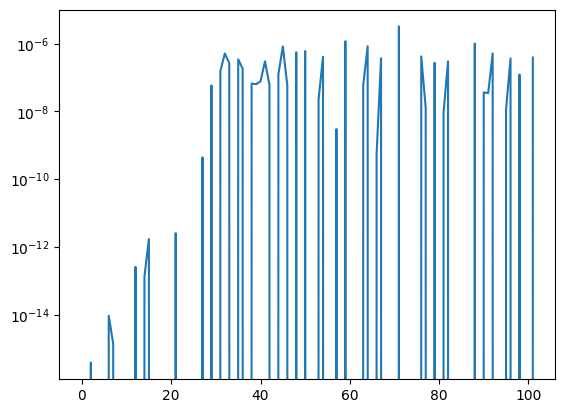

In [15]:
import matplotlib.pyplot as plt
plt.plot(-diag_e['sas'][:, 0, 1])
plt.yscale('log')

In [16]:
mat = diag_e['sas'][20]
d = jnp.diagonal(mat).real
modod = jnp.square(jnp.abs(mat[jnp.array([1, 2, 2]), jnp.array([0, 0, 1])]))
c2 = -jnp.sum(d)
c1 = jnp.sum(d * jnp.roll(d, 1)) - jnp.sum(modod)
c0 = jnp.sum(d * modod[::-1])
c0 -= jnp.prod(d)
c0 -= 2. * (mat[0, 2] * mat[1, 0] * mat[2, 1]).real
p = jnp.square(c2) - 3. * c1
q = -13.5 * c0 - c2 * c2 * c2 + 4.5 * c2 * c1
phi = jnp.atan2(jnp.sqrt(27. * (0.25 * jnp.square(c1) * (p - c1) + c0 * (q + 6.75 * c0))), q) / 3.
cphi = jnp.cos(phi)
sphi = jnp.sin(phi)

In [17]:
xvals = jnp.sort(jnp.array([2. * cphi, -cphi - jnp.sqrt(3.) * sphi, -cphi + jnp.sqrt(3.) * sphi]))
eigvals = jnp.sqrt(p) / 3. * xvals - c2 / 3.

In [18]:
eigvals

Array([-1.40000000e+01, -7.88549266e+00,  5.30091979e-08], dtype=float64)

In [33]:
mat

Array([[-1.40000000e+01,  1.03502693e-11,  1.74230398e-08],
       [ 1.03502484e-11, -7.88549260e+00, -6.90958578e-04],
       [ 1.74230398e-08, -6.90958578e-04, -7.53537436e-09]],      dtype=float64)

In [20]:
w, v = jnp.linalg.eigh(mat)

In [22]:
v

Array([[ 1.00000000e+00,  1.94241906e-12,  1.24450277e-09],
       [-1.83337072e-12,  9.99999996e-01, -8.76240212e-05],
       [-1.24450293e-09,  8.76240212e-05,  9.99999996e-01]],      dtype=float64)

In [ ]:
v0 = mat[:, 1].at[1].subtract(eigvals[0])
v1 = mat[:, 2].at[2].subtract(eigvals[0])
eigvec = jnp.cross(v0, v1).conjugate()
eigvec

Array([ 8.56031030e+01, -1.56942368e-10, -1.06533313e-07], dtype=float64)

In [24]:
mat - jnp.eye(3) * eigvals[0]

Array([[-7.10542736e-15,  1.03502693e-11,  1.74230398e-08],
       [ 1.03502484e-11,  6.11450740e+00, -6.90958578e-04],
       [ 1.74230398e-08, -6.90958578e-04,  1.40000000e+01]],      dtype=float64)

In [35]:
eigvec / jnp.linalg.norm(eigvec)

Array([ 1.00000000e+00, -1.83337242e-12, -1.24450293e-09], dtype=float64)

In [30]:
diag_e['P'][10:12]

Array([[-0.00988821,  0.00491072,  0.01356744, ..., -0.00713763,
        -0.01191027,  0.00376922],
       [ 0.01670273, -0.00248438, -0.01694345, ..., -0.00245074,
         0.0085177 , -0.01200083]], dtype=float64)